Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [50]:
# cell for imports. All imports must go here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [51]:
df = pd.read_csv('train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [52]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

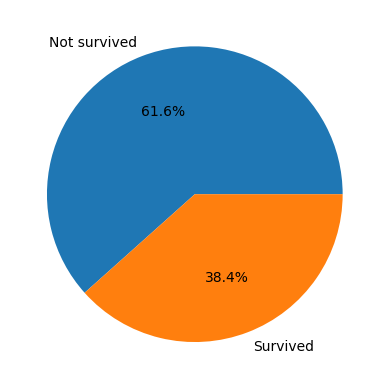

In [53]:
df['Survived'].value_counts().plot(kind='pie', labels=['Not survived', 'Survived'], autopct='%1.1f%%')
plt.ylabel("")
plt.show()

Кругова діаграма показує, що візуально сектор загиблих більший за сектор тих, хто вижив.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


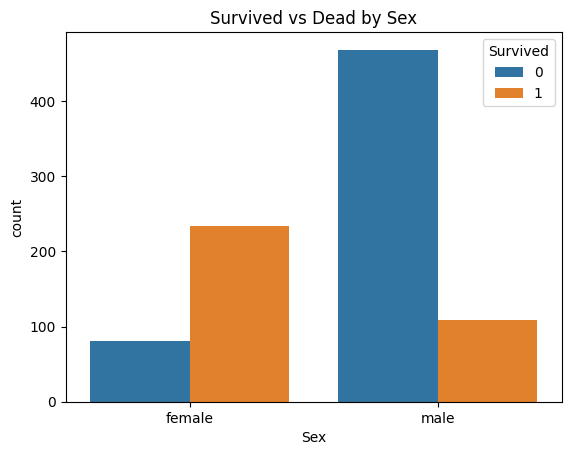

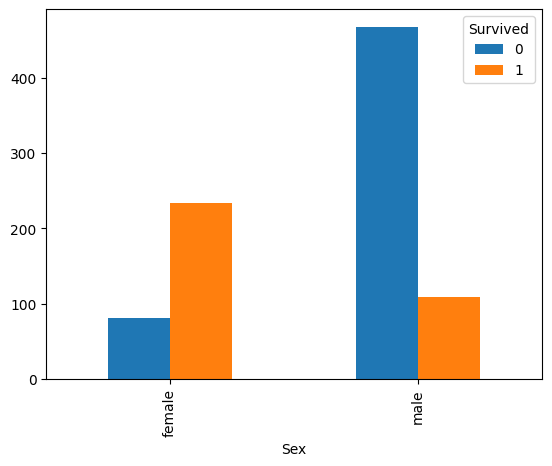

In [54]:
df.groupby(['Sex', 'Survived'], as_index=False).agg('size').pivot(index='Sex', columns='Survived', values='size').plot.bar()
plt.show()

Зі стовпчастої діаграми видно, що стовпець виживших жінок вищий за стовпець загиблих, тоді як серед чоловіків найвищим є стовпець загиблих.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

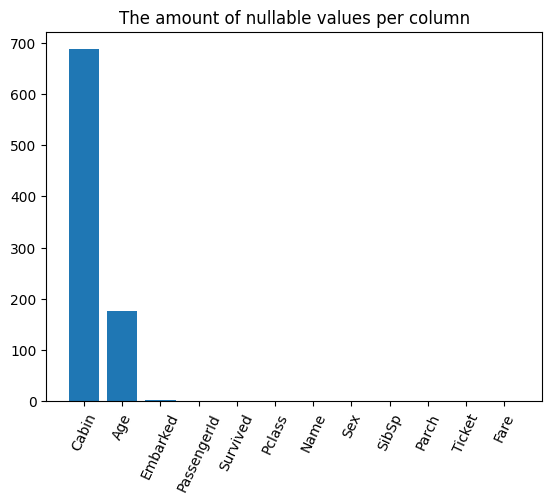

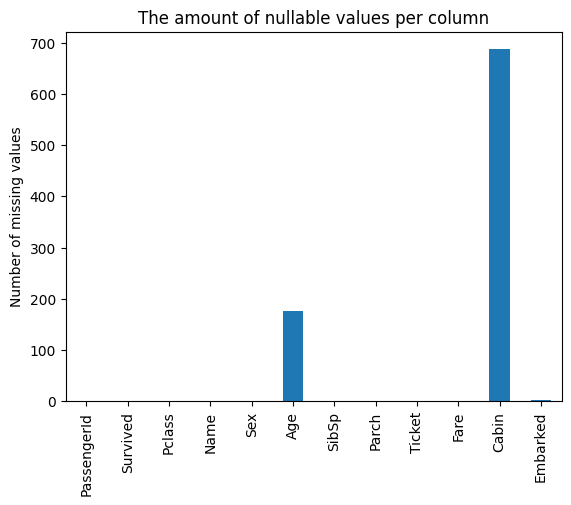

In [55]:
df.isna().sum().plot(kind='bar')
plt.ylabel('Number of missing values')
plt.title('The amount of nullable values per column')
plt.show()

На графіку видно, що найбільше пропущених значень має змінна Cabin. Також є значна кількість пропусків у змінній Age та зовсім небагато у Embarked. Усі інші змінні пропусків не мають.

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

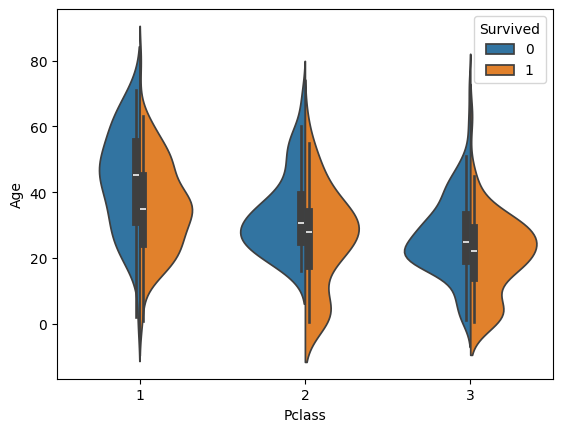

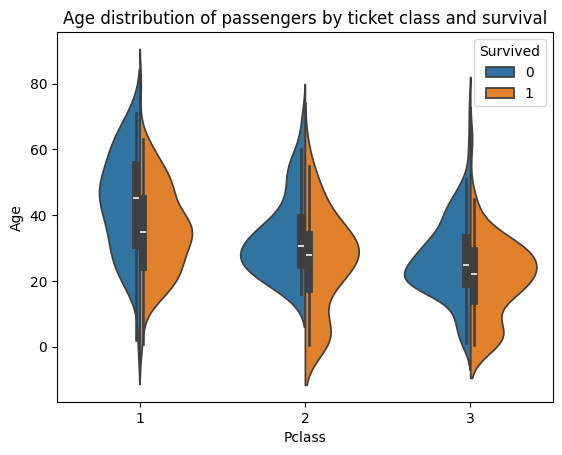

In [56]:
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', split=True)
plt.title('Age distribution of passengers by ticket class and survival')
plt.show()

Пасажири 1-го класу найстарші, 3-го — наймолодші. У всіх класах медіанний вік загиблих дещо вищий за тих, хто вижив. Загалом клас квитка корелює з віком, але суттєво не визначає шанси на виживання.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


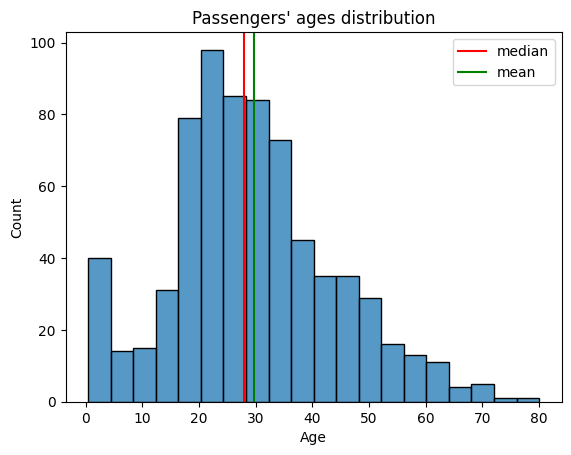

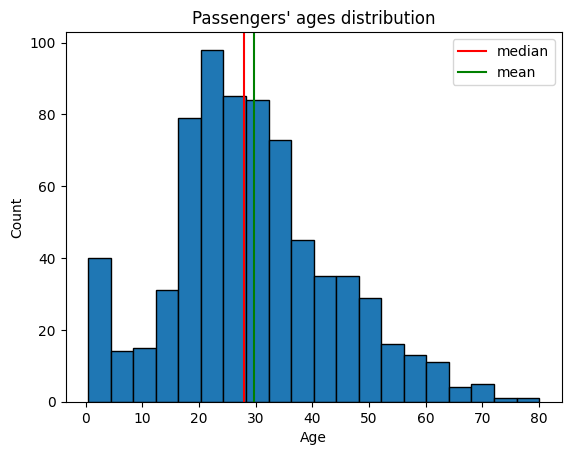

In [57]:
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.axvline(df['Age'].median(), color='red', label='median')
plt.axvline(df['Age'].mean(), color='green', label='mean')
plt.title("Passengers' ages distribution")
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

Більшість пасажирів Титаніка були молодими людьми віком 20–30 років. Невелика кількість літніх пасажирів зміщує середнє значення вправо відносно медіани. Також помітна висока частота дітей віком до 5 років.

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Як вартість проїзду залежить від порту відправлення?

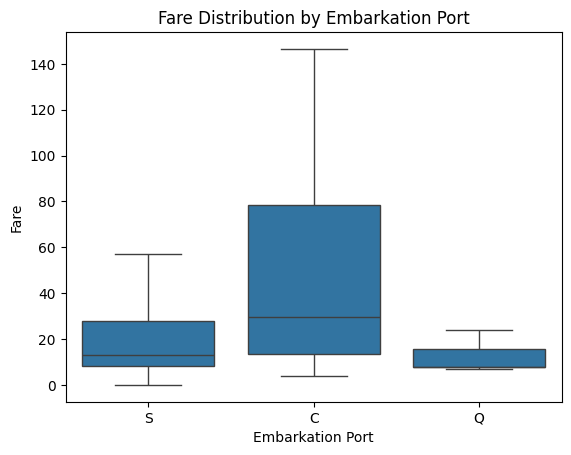

In [58]:
sns.boxplot(x='Embarked', y='Fare', data=df, showfliers=False)
plt.title('Fare Distribution by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Fare')
plt.show()

Графік наочно демонструє, що найдорожчі квитки купували пасажири в порту Шербур (C), тоді як Саутгемптон (S) відображає переважно середній рівень вартості з помірним розкидом. Натомість у Квінстауні (Q) майже всі квитки були однаково дешевими, що вказує на масову посадку бідних емігрантів у каюти третього класу.

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

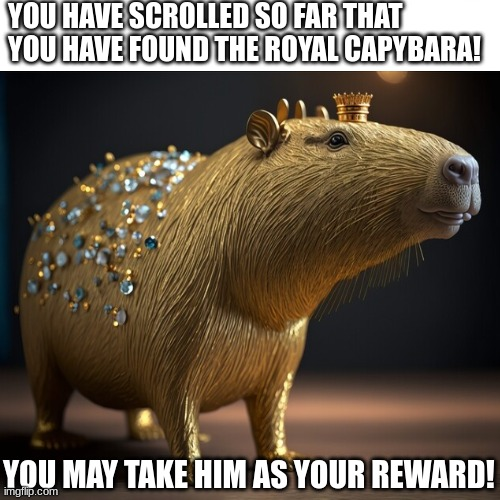